# RL Experiment Plots

Visualize training metrics from RL experiments across three settings:
- `real_world`
- `simulation`
- `simulation_with_real_world_input`

Metrics: `ep_len_mean`, `ep_rew_mean`, `top_score`

In [15]:
from tbparse import SummaryReader
import pandas as pd
import os

# log_dir = "/home/wsl/mygit/rwrl_backup/runs/AtlantisNoFrameskip-v4/DQN_1/events.out.tfevents.1773319891.A512025.293052.0"
# output_dir = "/home/wsl/mygit/rwrl_backup/runs/AtlantisNoFrameskip-v4/DQN_1/"
# log_dir = "C:\\GitHub\\data_and_plot\\wgzqrmn3\\tensorboard\\breakout_20260401_000009\\events.out.tfevents.1774962009.b3611ff33acb.2909.0"
# output_dir = "C:\\GitHub\\data_and_plot\\ep_rew_mean\\wgzqrmn3\\"
log_dir = "C:\\GitHub\\data_and_plot\\wgzqrmn3\\tensorboard\\breakout_20260529_224645\\events.out.tfevents.1780058805.b3611ff33acb.7836.0"
output_dir = "C:\\GitHub\\data_and_plot\\wgzqrmn3\\csv\\breakout_20260529\\"
# log_dir = "C:\\GitHub\\data_and_plot\\10_66_28_74\\tensorboard\\breakout_20260424_231658\\events.out.tfevents.1777036618.f9131d64a981.2853.0"
# output_dir = "C:\\GitHub\\data_and_plot\\10_66_28_74\\csv\\breakout_20260424_231658\\"

os.makedirs(output_dir, exist_ok=True)

reader = SummaryReader(log_dir, extra_columns={'wall_time'})

# Export scalars
df = reader.scalars
df.to_csv(os.path.join(output_dir, "scalars.csv"), index=False)

for tag, group in df.groupby("tag"):
    safe_tag = tag.split("/", 1)[-1]
    print(f"Exporting tag: {tag} to {safe_tag}.csv with columns: {group.columns.tolist()}")

    # Drop tag and dir_name columns if they exist
    group = group.drop(columns=["tag"], errors="ignore")

    # If wall_time exists, move it to the front
    if "wall_time" in group.columns:
        cols = ["wall_time"] + [c for c in group.columns if c != "wall_time"]
        group = group[cols]
    # Rename wall_time → "Wall time"
    group = group.rename(columns={"wall_time": "Wall time"})
    group.columns = [col.capitalize() for col in group.columns]

    out_path = os.path.join(output_dir, f"{safe_tag}.csv")
    group.to_csv(out_path, index=False)

# # Export histograms
# if reader.histograms is not None:
#     reader.histograms.to_csv(os.path.join(output_dir, "histograms.csv"), index=False)

# # Export tensors
# if reader.tensors is not None:
#     reader.tensors.to_csv(os.path.join(output_dir, "tensors.csv"), index=False)

# # Export text
# if reader.text is not None:
#     reader.text.to_csv(os.path.join(output_dir, "text.csv"), index=False)

# # Export images metadata (not the raw images)
# if reader.images is not None:
#     reader.images.to_csv(os.path.join(output_dir, "images.csv"), index=False)

print("All TensorBoard data exported to CSV.")

Exporting tag: rollout/ep_len_mean to ep_len_mean.csv with columns: ['step', 'tag', 'value', 'wall_time']
Exporting tag: rollout/ep_rew_mean to ep_rew_mean.csv with columns: ['step', 'tag', 'value', 'wall_time']
Exporting tag: rollout/exploration_rate to exploration_rate.csv with columns: ['step', 'tag', 'value', 'wall_time']
Exporting tag: rollout/top_score to top_score.csv with columns: ['step', 'tag', 'value', 'wall_time']
Exporting tag: time/episodes to episodes.csv with columns: ['step', 'tag', 'value', 'wall_time']
Exporting tag: time/fps to fps.csv with columns: ['step', 'tag', 'value', 'wall_time']
Exporting tag: time/total_steps to total_steps.csv with columns: ['step', 'tag', 'value', 'wall_time']
Exporting tag: train/loss to loss.csv with columns: ['step', 'tag', 'value', 'wall_time']
All TensorBoard data exported to CSV.


In [26]:
import sys
from pathlib import Path
import importlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

root_dir = Path("..").resolve()
if str(root_dir) not in sys.path:
    sys.path.append(str(root_dir))

import plot_functions
importlib.reload(plot_functions)
from plot_functions import plot_learning_curves

import style
importlib.reload(style)
from style import MatplotlibStyle

mpl_style = MatplotlibStyle()
mpl_style.apply()

In [27]:
def read_rl_csv(metric: str, key: str, base_dir: str = ".") -> pd.DataFrame:
    """
    Read an RL training CSV file by metric folder and file key.

    Args:
        metric:   subfolder name, e.g. "ep_len_mean", "ep_rew_mean", "top_score"
        key:      file stem, e.g. "real_world", "simulation",
                  "simulation_with_real_world_input"
        base_dir: root directory that contains the metric folders (default: ".")

    Returns:
        DataFrame with columns "Step" (x-axis) and "Value" (y-axis).
    """
    path = Path(base_dir) / metric / f"{key}.csv"
    print(f"real csv file {path}")
    df = pd.read_csv(path)
    return df[["Step", "Value"]].reset_index(drop=True)


def load_hns_scores(files_dict: dict, random_score: float, human_score: float) -> dict:
    """
    Load episode-score arrays from .npz files and convert to Human Normalized Score.

    Args:
        files_dict:   dict mapping label -> path to .npz file containing key 'array'.
        random_score: random-agent baseline score for the game.
        human_score:  human reference score for the game.

    Returns:
        dict mapping label -> 1-D numpy array of HNS values.
    """
    hns = {}
    for label, path in files_dict.items():
        raw = np.load(path)['array'].astype(float)
        hns[label] = (raw - random_score) / (human_score - random_score)
    return hns


In [28]:
from scipy.stats import bootstrap as _scipy_bootstrap


# ── Helper statistics ────────────────────────────────────────────────────────
def _iqm(x):
    """Interquartile Mean: mean of scores in the [Q25, Q75] range."""
    q25, q75 = np.percentile(x, [25, 75])
    return np.mean(x[(x >= q25) & (x <= q75)])


def _bootstrap_ci(data, stat_fn, n_resamples=10_000, ci=0.95, seed=0):
    """Return (point_estimate, ci_low, ci_high) via percentile bootstrap."""
    result = _scipy_bootstrap(
        (data,), stat_fn,
        n_resamples=n_resamples,
        confidence_level=ci,
        method='percentile',
        random_state=seed,
    )
    return stat_fn(data), result.confidence_interval.low, result.confidence_interval.high


# ── Plotting function ────────────────────────────────────────────────────────
def plot_interval_estimates(
    hns_scores,
    metric='Median',
    system_order=None,
    colours=None,
    figsize=(6.0, 2.6),
    bar_height=0.45,
    n_resamples=10_000,
    ci=0.95,
    save_path=None,
    dpi=800,
    fontsize_title=None,
    fontsize_label=None,
    fontsize_tick=None,
):
    """
    Plot a single interval-estimate bar chart for one statistic (Median / IQM / Mean).
    Font sizes fall back to rcParams values when not explicitly provided.

    Args:
        hns_scores:    dict mapping system label -> 1-D numpy array of HNS values.
        metric:        statistic to display: 'Median', 'IQM', or 'Mean'.
        system_order:  list of labels in display order (top to bottom).
                       Defaults to hns_scores.keys().
        colours:       dict mapping label -> colour string. Defaults to built-in palette.
        figsize:       figure size (width, height) in inches.
        bar_height:    height of each CI bar (0–1).
        n_resamples:   bootstrap resamples for CI estimation.
        ci:            confidence level, e.g. 0.95 for 95% CI.
        save_path:     if given, saves figure as <save_path>.pdf.
        dpi:           resolution for saved figure.
        fontsize_title: title font size (default: rcParams axes.titlesize).
        fontsize_label: x-axis label font size (default: rcParams axes.labelsize).
        fontsize_tick:  tick label font size (default: rcParams xtick.labelsize).
    """
    _STAT_FNS = {'Median': np.median, 'IQM': _iqm, 'Mean': np.mean}
    if metric not in _STAT_FNS:
        raise ValueError(f"metric must be one of {list(_STAT_FNS.keys())}, got '{metric}'")
    stat_fn = _STAT_FNS[metric]

    _title_fs = fontsize_title or plt.rcParams.get("axes.titlesize",  14)
    _label_fs = fontsize_label or plt.rcParams.get("axes.labelsize",  13)
    _tick_fs  = fontsize_tick  or plt.rcParams.get("xtick.labelsize", 11)

    _DEFAULT_COLOURS = {
        'simulation':        '#2BAAAB',
        'real world input':  '#E8A817',
        'real world system': '#3A88C5',
    }
    if colours is None:
        colours = _DEFAULT_COLOURS
        color_palette='colorblind'
        color_palette = sns.color_palette(color_palette, n_colors=len(hns_scores.keys()))
        colours = dict(zip(hns_scores.keys(), color_palette))
    if system_order is None:
        system_order = list(hns_scores.keys())

    fig, ax = plt.subplots(figsize=figsize)

    for yi, label in enumerate(system_order):
        data = hns_scores[label]
        pt, lo, hi = _bootstrap_ci(data, stat_fn, n_resamples=n_resamples, ci=ci)
        color = colours.get(label, 'steelblue')

        ax.barh(yi, hi - lo, left=lo, height=bar_height,
                color=color, alpha=0.85, linewidth=0)
        ax.plot([pt, pt], [yi - bar_height / 2, yi + bar_height / 2],
                color='black', linewidth=1.8, solid_capstyle='round')

    ax.set_yticks(range(len(system_order)))
    ax.set_yticklabels(system_order, fontsize=_tick_fs)
    ax.set_xlabel('Human Normalized Score', fontsize=_label_fs)
    ax.set_title(metric, fontsize=_title_fs, pad=6)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.tick_params(axis='y', length=0)
    ax.tick_params(axis='x', labelsize=_tick_fs)
    ax.grid(axis='x', linestyle='--', linewidth=0.6, alpha=0.5)

    if save_path:
        fig.savefig(f'{save_path}.png', dpi=dpi, bbox_inches='tight')
    fig.tight_layout()
    plt.show()


In [29]:
def plot_rl_curves(
    data_dict,
    colors=None,
    legend_map=None,
    title="RL Learning Curves",
    x_label="Step",
    y_label="Value",
    y_lim=None,
    figsize=(10, 6),
    window_size=10,
    is_legend=True,
    save_path=None,
    plot_raw=True,
    raw_alpha=0.35,
    raw_linewidth=0.7,
    smooth_linewidth=2,
    dpi=800,
    fontsize_title=None,
    fontsize_label=None,
    fontsize_legend=None,
    fontsize_tick=None,
    skip_color = 0,
):
    """
    Plot RL training curves with optional rolling-average smoothing.
    Uses MatplotlibStyle settings (font, colors, tick sizes) applied globally.
    Font sizes fall back to rcParams values when not explicitly provided.

    Args:
        data_dict:       dict mapping key -> DataFrame with "Step" and "Value" columns.
        colors:          list of line colors; if None, uses the style's prop_cycle colors.
        legend_map:      dict mapping key -> display label.
        y_lim:           (min, max) for y-axis, or None for auto.
        window_size:     rolling-average window (1 = no smoothing).
        save_path:       if given, saves figure as <save_path>.pdf.
        plot_raw:        overlay raw dashed trace under the smoothed line.
        fontsize_title:  title font size (default: rcParams axes.titlesize).
        fontsize_label:  x/y axis label font size (default: rcParams axes.labelsize).
        fontsize_legend: legend font size (default: rcParams legend.fontsize).
        fontsize_tick:   tick label font size (default: rcParams xtick/ytick.labelsize).
    """
    # Resolve font sizes from rcParams if not provided
    _title_fs  = fontsize_title  or plt.rcParams.get("axes.titlesize",  20)
    _label_fs  = fontsize_label  or plt.rcParams.get("axes.labelsize",  24)
    _legend_fs = fontsize_legend or plt.rcParams.get("legend.fontsize", 20)
    _tick_fs   = fontsize_tick   or plt.rcParams.get("xtick.labelsize", 20)

    # Resolve colors: use provided list, style prop_cycle, or a safe fallback
    if colors is None:
        prop_cycle = plt.rcParams.get("axes.prop_cycle", None)
        colors = [c["color"] for c in prop_cycle] if prop_cycle else \
                 ["red", "green", "blue", "orange", "purple", "brown"]
        color_palette='colorblind'
        # color_palette = sns.color_palette(color_palette, n_colors=len(data_dict))
        color_palette = sns.color_palette(color_palette, n_colors=len(data_dict)+skip_color)
        colors = dict(zip(data_dict, color_palette))
        print(colors)
    if len(colors) < len(data_dict):
        colors = [colors[i % len(colors)] for i in range(len(data_dict))]
        color_palette='colorblind'
        color_palette = sns.color_palette(color_palette, n_colors=len(data_dict))
        colors = dict(zip(data_dict, color_palette))
    fig, ax = plt.subplots(figsize=figsize)

    for idx, (key, df) in enumerate(data_dict.items()):
        label = legend_map.get(key, str(key)) if legend_map else str(key)
        steps = df["Step"].values
        values = df["Value"].values
        print(f"key: {key}")
        color = colors[key]
        # color = colors[idx]

        if plot_raw:
            ax.plot(steps, values, linestyle="dashed", linewidth=raw_linewidth,
                    alpha=raw_alpha, color=color)

        if len(values) >= window_size:
            smoothed = pd.Series(values).rolling(window=window_size, min_periods=1).mean().values
            ax.plot(steps, smoothed, color=color, linewidth=smooth_linewidth, label=label)
        else:
            ax.plot(steps, values, color=color, linewidth=smooth_linewidth, label=label)

    # handles, labels = ax.get_legend_handles_labels()
    # ax.legend(shadow=True, fontsize='x-large', reverse=True)
    if y_lim is not None:
        ax.set_ylim(y_lim)
    ax.set_title(title, fontsize=_title_fs)
    ax.set_xlabel(x_label, fontsize=_label_fs)
    ax.set_ylabel(y_label, fontsize=_label_fs)
    ax.tick_params(axis="x", labelsize=_tick_fs)
    ax.tick_params(axis="y", labelsize=_tick_fs)
    if is_legend:
        ax.legend(fontsize=_legend_fs, reverse=True)
    if save_path:
        fig.savefig(f"{save_path}.pdf", dpi=dpi, bbox_inches="tight")
    fig.tight_layout()
    plt.show()

## Episode Length Mean (`ep_len_mean`)

real csv file ep_len_mean\real_world.csv
real csv file ep_len_mean\simulation_with_real_world_input.csv
real csv file ep_len_mean\simulation.csv
{'real_world': (0.00392156862745098, 0.45098039215686275, 0.6980392156862745), 'simulation_with_real_world_input': (0.8705882352941177, 0.5607843137254902, 0.0196078431372549), 'simulation': (0.00784313725490196, 0.6196078431372549, 0.45098039215686275)}
key: real_world
key: simulation_with_real_world_input
key: simulation


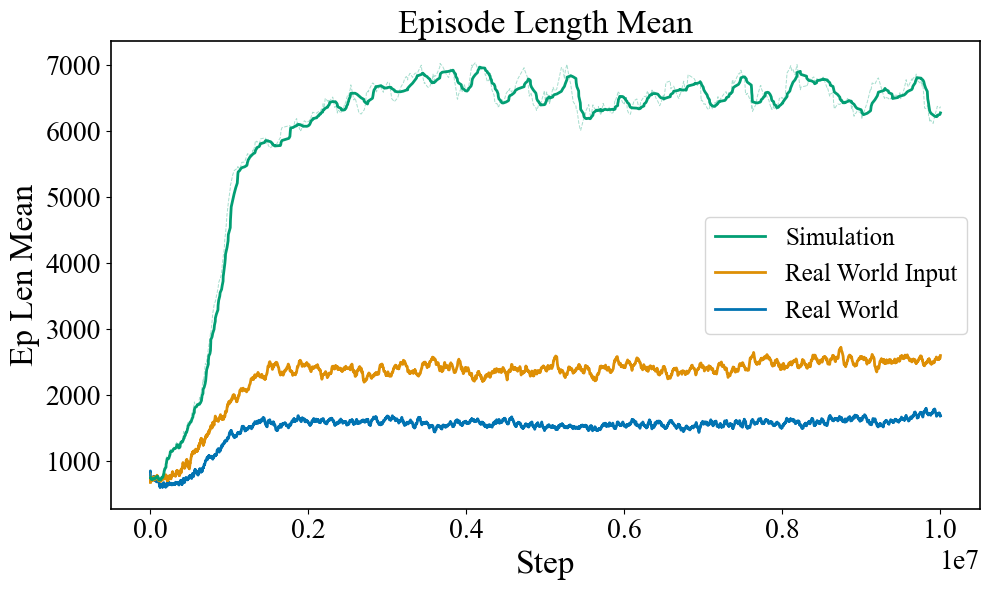

In [30]:
# keys = ["simulation", "simulation_with_real_world_input", "real_world"]
keys = ["real_world", "simulation_with_real_world_input", "simulation"]
legend_map = {
    "real_world": "Real World",
    "simulation_with_real_world_input": "Real World Input",
    "simulation": "Simulation",
}

data_ep_len = {key: read_rl_csv("ep_len_mean", key) for key in keys}

plot_rl_curves(
    data_ep_len,
    legend_map=legend_map,
    title="Episode Length Mean",
    x_label="Step",
    y_label="Ep Len Mean",
    figsize=(10, 6),
    window_size=10,
    save_path='three_system_len',
    is_legend=True,
)

## Episode Reward Mean (`ep_rew_mean`)

real csv file ep_rew_mean\real_world.csv
real csv file ep_rew_mean\simulation_with_real_world_input.csv
real csv file ep_rew_mean\simulation.csv
{'real_world': (0.00392156862745098, 0.45098039215686275, 0.6980392156862745), 'simulation_with_real_world_input': (0.8705882352941177, 0.5607843137254902, 0.0196078431372549), 'simulation': (0.00784313725490196, 0.6196078431372549, 0.45098039215686275)}
key: real_world
key: simulation_with_real_world_input
key: simulation


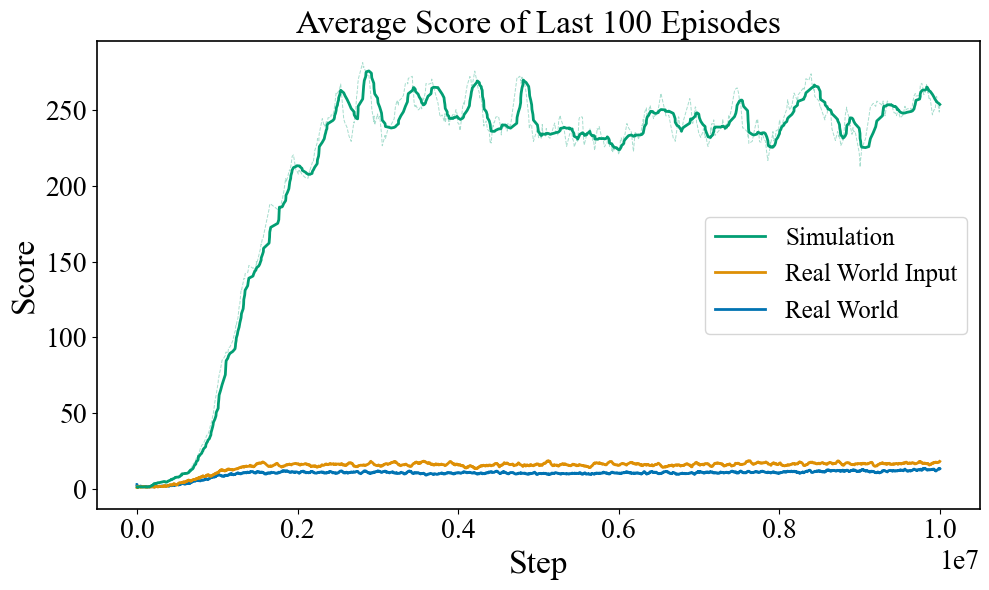

In [31]:
data_ep_rew = {key: read_rl_csv("ep_rew_mean", key) for key in keys}

plot_rl_curves(
    data_ep_rew,
    legend_map=legend_map,
    title="Average Score of Last 100 Episodes",
    x_label="Step",
    y_label="Score",
    figsize=(10, 6),
    window_size=10,
    save_path='three_system',
    is_legend=True,
)

real csv file ep_rew_mean\real_world.csv
real csv file ep_rew_mean\simulation_with_real_world_input.csv
{'real_world': (0.00392156862745098, 0.45098039215686275, 0.6980392156862745), 'simulation_with_real_world_input': (0.8705882352941177, 0.5607843137254902, 0.0196078431372549)}
key: real_world
key: simulation_with_real_world_input


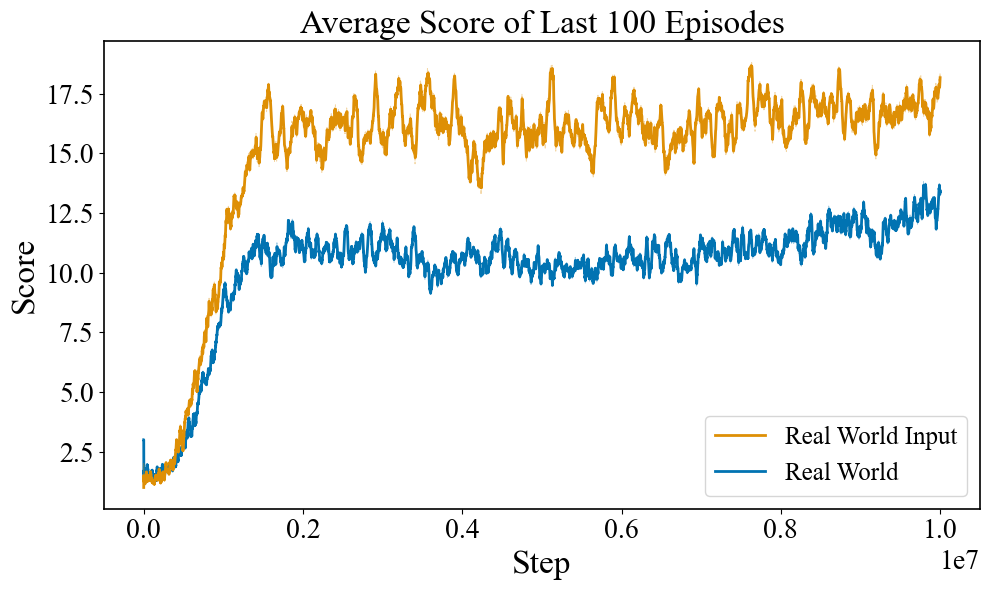

In [32]:
keys = ["real_world", "simulation_with_real_world_input", "simulation"]
legend_map = {
    "real_world": "Real World",
    "simulation_with_real_world_input": "Real World Input",
    "simulation": "Simulation",
}

keys = ["real_world", "simulation_with_real_world_input"]
data_ep_rew = {key: read_rl_csv("ep_rew_mean", key) for key in keys}

plot_rl_curves(
    data_ep_rew,
    legend_map=legend_map,
    # colors=["green", "dodgerblue"],
    title="Average Score of Last 100 Episodes",
    x_label="Step",
    y_label="Score",
    figsize=(10, 6),
    window_size=10,
    save_path='two_system',
    is_legend=True,
    skip_color=1,
)

## Top Score (`top_score`)

real csv file top_score\real_world.csv
real csv file top_score\simulation_with_real_world_input.csv
{'real_world': (0.00392156862745098, 0.45098039215686275, 0.6980392156862745), 'simulation_with_real_world_input': (0.8705882352941177, 0.5607843137254902, 0.0196078431372549)}
key: real_world
key: simulation_with_real_world_input


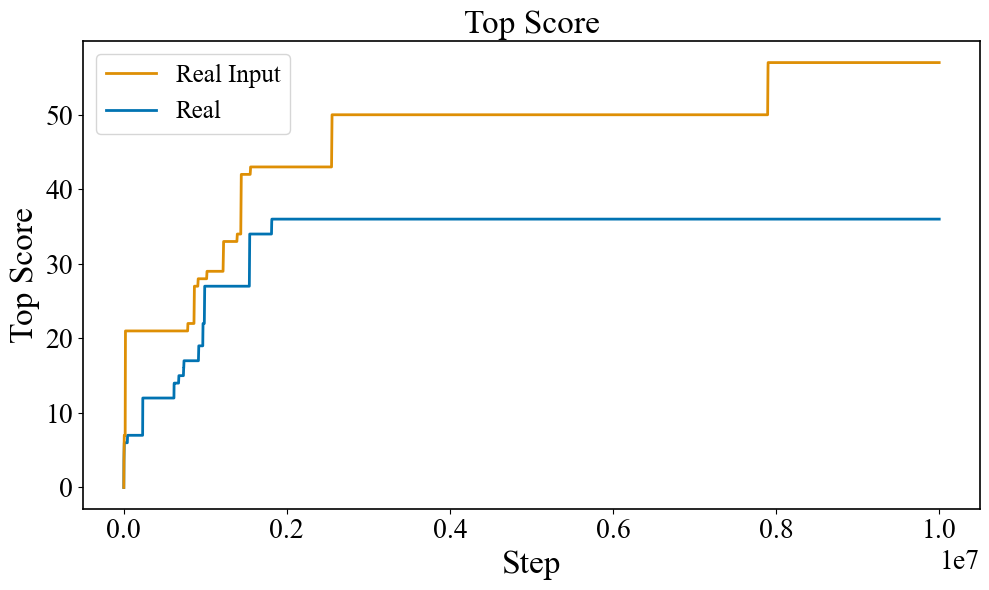

In [40]:
data_top_score = {key: read_rl_csv("top_score", key) for key in keys}

plot_rl_curves(
    data_top_score,
    legend_map=legend_map,
    title="Top Score",
    x_label="Step",
    y_label="Top Score",
    figsize=(10, 6),
    window_size=10,
    is_legend=True,
)

## Time Cost Comparison (Bar Chart)

Compare the **total wall-clock time consumed** by each setting across equal-length step intervals.

In [34]:
def read_rl_csv_full(metric: str, key: str, base_dir: str = ".") -> pd.DataFrame:
    """Read RL CSV with Wall time, Step, Value columns."""
    path = Path(base_dir) / metric / f"{key}.csv"
    df = pd.read_csv(path)
    return df[["Wall time", "Step", "Value"]].reset_index(drop=True)


def plot_time_cost_bar(
    metric: str = "ep_len_mean",
    keys: list = None,
    legend_map: dict = None,
    base_dir: str = ".",
    title: str = "Total Time Cost Comparison",
    # x_label: str = "Time Cost (s)",
    x_label: str = " ",
    y_label: str = " ",
    figsize: tuple = (8, 4),
    colors: list = None,
    save_path: str = None,
    dpi: int = 800,
    fontsize_title=None,
    fontsize_label=None,
    fontsize_tick=None,
    horizontal = True,
):
    """
    Plot a horizontal bar chart of total wall-clock time cost per setting.

    The total time is computed as:  max(Wall time) - min(Wall time).

    Args:
        metric:         which metric folder to read (only Wall time is used).
        keys:           list of file stems (settings).
        legend_map:     dict mapping key -> display label.
        base_dir:       root directory containing metric sub-folders.
        title:          chart title.
        x_label:        x-axis label.
        y_label:        y-axis label.
        figsize:        figure size (width, height) in inches.
        colors:         list of bar colours; if None, uses the style prop_cycle.
        save_path:      if given, saves the figure as <save_path>.pdf.
        dpi:            resolution for saved figure.
        fontsize_title: title font size (default: rcParams axes.titlesize).
        fontsize_label: axis label font size (default: rcParams axes.labelsize).
        fontsize_tick:  tick label font size (default: rcParams xtick.labelsize).
    """
    if keys is None:
        if horizontal:
            keys=["real_world", "simulation_with_real_world_input", "simulation"]
        else:
            keys=["simulation", "simulation_with_real_world_input", "real_world"]
            # keys=["real_world", "simulation_with_real_world_input", "simulation"]
        # keys = ["real_world", "simulation", "simulation_with_real_world_input"]
        # keys = ["real_world", "simulation_with_real_world_input", "simulation"]

    _title_fs = fontsize_title or plt.rcParams.get("axes.titlesize",  14)
    _label_fs = fontsize_label or plt.rcParams.get("axes.labelsize",  12)
    _tick_fs  = fontsize_tick  or plt.rcParams.get("xtick.labelsize", 10)

    # Load data and compute total wall-clock time per key
    total_times = {}
    for key in keys:
        print("key: ", key)
        df = read_rl_csv_full(metric, key, base_dir)
        total_times[key] = (df["Wall time"].max() - df["Wall time"].min())/3600/24

    # Resolve colors
    if colors is None:
        prop_cycle = plt.rcParams.get("axes.prop_cycle", None)
        # color_palette = sns.color_palette(color_palette, n_colors=len(algorithms)+1)
        colors = [c["color"] for c in prop_cycle] if prop_cycle else \
                 ["red", "green", "blue", "orange", "purple"]
        color_palette='colorblind'
        color_palette = sns.color_palette(color_palette, n_colors=len(keys))
        colors = dict(zip(keys, color_palette))
        print(colors)
    labels = [legend_map.get(k, k) if legend_map else k for k in keys]
    print(labels)

    values = [total_times[k] for k in keys]
    print(values)
    # bar_colors = [colors[i % len(colors)] for i in range(len(keys))]
    if horizontal:
        bar_colors = [colors[key] for key in keys]
    else:
        bar_colors = [colors[key] for key in keys][::-1]
    print(f"bar_colors: {bar_colors}")

    if horizontal:
        figsize = (5, 5)
        x_label = "Days"
    else:
        figsize = (5, 5)
        y_label = "Days"
    fig, ax = plt.subplots(figsize=figsize)
    # x = range(len(labels))
    if horizontal:
        bars = ax.barh(labels, values, height = 0.7, color=bar_colors, edgecolor="white", linewidth=0.5)
        # bars = ax.barh(labels, values, color=colors, edgecolor="white", linewidth=0.5)
        ax.set_xlim(right=max(values) * 1.1)
    else:
        bars = ax.bar(labels, values, width =0.7, color=bar_colors)
        ax.bar_label(bars, padding=3, fontsize=18, fmt="%.1f")
        ax.set_ylim(top=max(values) * 1.1)
        # ax.set_xticklabels(labels, rotation=90)
        # plt.xticks(rotation=90) 

    # ax.set_title(title, fontsize=_title_fs, pad=8)
    # ax.set_xlabel(x_label, fontsize=_label_fs)
    ax.set_ylabel(y_label, fontsize=_label_fs)
    # ax.tick_params(axis="x", labelsize=_tick_fs)
    ax.tick_params(axis="y", labelsize=_tick_fs)
    
    if save_path:
        fig.savefig(f"{save_path}.pdf", dpi=dpi, bbox_inches="tight")
    fig.tight_layout()
    plt.show()


key:  simulation
key:  simulation_with_real_world_input
key:  real_world
{'simulation': (0.00392156862745098, 0.45098039215686275, 0.6980392156862745), 'simulation_with_real_world_input': (0.8705882352941177, 0.5607843137254902, 0.0196078431372549), 'real_world': (0.00784313725490196, 0.6196078431372549, 0.45098039215686275)}
['Sim', 'Real Input', 'Real']
[np.float64(1.4435714819282293), np.float64(8.158315157432247), np.float64(10.45353090359105)]
bar_colors: [(0.00784313725490196, 0.6196078431372549, 0.45098039215686275), (0.8705882352941177, 0.5607843137254902, 0.0196078431372549), (0.00392156862745098, 0.45098039215686275, 0.6980392156862745)]


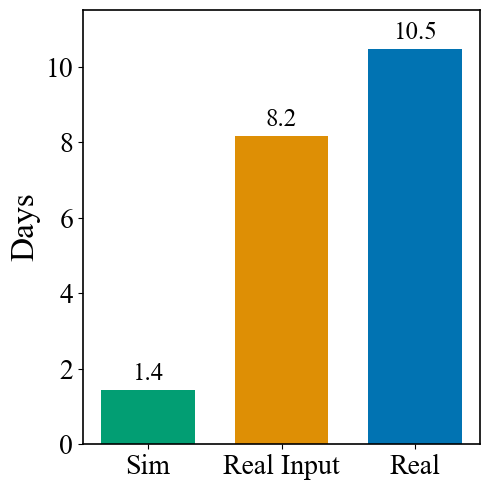

In [35]:
legend_map = {
    "real_world": "Real",
    "simulation_with_real_world_input": "Real Input",
    "simulation": "Sim",
}

plot_time_cost_bar(
    metric="ep_len_mean",
    # keys=["real_world", "simulation_with_real_world_input", "simulation"],
    legend_map=legend_map,
    base_dir=".",
    # colors=["red", "green", "dodgerblue"],
    title="Training Time",
    # title="Total Training Time for 10 Million Steps",
    # y_label="Days",
    # figsize=(4, 8),
    save_path="time_cost_bar",
    horizontal = False,
)

In [36]:
def plot_maximum_score_bar(
    metric: str = "ep_rew_mean",
    keys: list = None,
    legend_map: dict = None,
    base_dir: str = ".",
    title: str = "Total Time Cost Comparison",
    # x_label: str = "Time Cost (s)",
    x_label: str = " ",
    y_label: str = " ",
    figsize: tuple = (8, 4),
    colors: list = None,
    save_path: str = None,
    dpi: int = 800,
    fontsize_title=None,
    fontsize_label=None,
    fontsize_tick=None,
    horizontal = True,
):
    """
    Plot a horizontal bar chart of total wall-clock time cost per setting.

    The total time is computed as:  max(Wall time) - min(Wall time).

    Args:
        metric:         which metric folder to read (only Wall time is used).
        keys:           list of file stems (settings).
        legend_map:     dict mapping key -> display label.
        base_dir:       root directory containing metric sub-folders.
        title:          chart title.
        x_label:        x-axis label.
        y_label:        y-axis label.
        figsize:        figure size (width, height) in inches.
        colors:         list of bar colours; if None, uses the style prop_cycle.
        save_path:      if given, saves the figure as <save_path>.pdf.
        dpi:            resolution for saved figure.
        fontsize_title: title font size (default: rcParams axes.titlesize).
        fontsize_label: axis label font size (default: rcParams axes.labelsize).
        fontsize_tick:  tick label font size (default: rcParams xtick.labelsize).
    """
    if keys is None:
        if horizontal:
            keys=["real_world", "simulation_with_real_world_input", "simulation"]
        else:
            keys=["simulation", "simulation_with_real_world_input", "real_world"]
        # keys = ["real_world", "simulation", "simulation_with_real_world_input"]
        # keys = ["real_world", "simulation_with_real_world_input", "simulation"]

    _title_fs = fontsize_title or plt.rcParams.get("axes.titlesize",  14)
    _label_fs = fontsize_label or plt.rcParams.get("axes.labelsize",  12)
    _tick_fs  = fontsize_tick  or plt.rcParams.get("xtick.labelsize", 10)

    # Load data and compute total wall-clock time per key
    max_mean_score = {}
    for key in keys:
        print("key: ", key)
        df = read_rl_csv_full(metric, key, base_dir)
        max_mean_score[key] = df["Value"].max()

    # Resolve colors
    if colors is None:
        prop_cycle = plt.rcParams.get("axes.prop_cycle", None)
        # color_palette = sns.color_palette(color_palette, n_colors=len(algorithms)+1)
        colors = [c["color"] for c in prop_cycle] if prop_cycle else \
                 ["red", "green", "blue", "orange", "purple"]
        color_palette='colorblind'
        color_palette = sns.color_palette(color_palette, n_colors=len(keys))
        colors = dict(zip(keys, color_palette))
        print(colors)
    labels = [legend_map.get(k, k) if legend_map else k for k in keys]
    print(labels)
    values = [max_mean_score[k] for k in keys]
    # bar_colors = [colors[i % len(colors)] for i in range(len(keys))]
    bar_colors = [colors[key] for key in keys][::-1]
    print(f"bar_colors: {bar_colors}")

    if horizontal:
        figsize = (8, 4)
        x_label = "Scores"
    else:
        figsize = (5, 5)
        y_label = "Scores"
    fig, ax = plt.subplots(figsize=figsize)
    # x = range(len(labels))
    if horizontal:
        bars = ax.barh(labels, values, color=bar_colors, edgecolor="white", linewidth=0.5)
        # bars = ax.barh(labels, values, color=colors, edgecolor="white", linewidth=0.5)
        ax.set_xlim(right=max(values) * 1.1)
    else:
        bars = ax.bar(labels, values, width=0.7, color=bar_colors)
        ax.bar_label(bars, padding=3, fontsize=18, fmt="%.1f")
        ax.set_ylim(top=max(values) * 1.1)
        # ax.set_xticklabels(labels, rotation=90)
        # plt.xticks(rotation=90)



    # ax.set_title(title, fontsize=_title_fs, pad=8)
    # ax.set_xlabel(x_label, fontsize=_label_fs)
    ax.set_ylabel(y_label, fontsize=_label_fs)
    # ax.tick_params(axis="x", labelsize=_tick_fs)
    ax.tick_params(axis="y", labelsize=_tick_fs)
    plt.subplots_adjust(bottom=0.05)
    

    if save_path:
        fig.savefig(f"{save_path}.pdf", dpi=dpi, bbox_inches="tight")
    fig.tight_layout()
    plt.show()

key:  simulation
key:  simulation_with_real_world_input
key:  real_world
{'simulation': (0.00392156862745098, 0.45098039215686275, 0.6980392156862745), 'simulation_with_real_world_input': (0.8705882352941177, 0.5607843137254902, 0.0196078431372549), 'real_world': (0.00784313725490196, 0.6196078431372549, 0.45098039215686275)}
['Sim', 'Real Input', 'Real']
bar_colors: [(0.00784313725490196, 0.6196078431372549, 0.45098039215686275), (0.8705882352941177, 0.5607843137254902, 0.0196078431372549), (0.00392156862745098, 0.45098039215686275, 0.6980392156862745)]


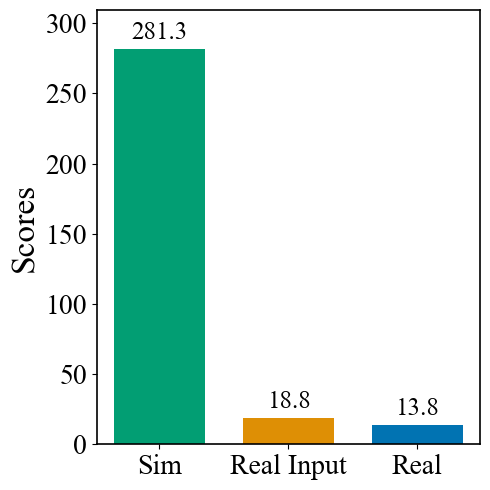

In [37]:
legend_map = {
    "real_world": "Real",
    "simulation_with_real_world_input": "Real Input",
    "simulation": "Sim",
}
plot_maximum_score_bar(
    metric="ep_rew_mean",
    # keys=["real_world", "simulation_with_real_world_input", "simulation"],
    legend_map=legend_map,
    base_dir=".",
    # colors=["red", "green", "dodgerblue"],
    title="Maximum Score",
    # y_label="Days",
    # figsize=(4, 8),
    save_path="max_score_bar",
    horizontal = False,
)

## Three Systems Comparison — Interval Estimates (Median / IQM / Mean)

In [ ]:
plot_interval_estimates(
    hns_scores,
    metric='IQM',
    system_order=SYSTEM_ORDER,
    figsize=(10, 6),
    save_path='three_systems_iqm',
)

In [ ]:
plot_interval_estimates(
    hns_scores,
    metric='Mean',
    system_order=SYSTEM_ORDER,
    figsize=(10, 6),
    save_path='three_systems_mean',
)
